In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as scp
import uproot
import matplotlib
from dash.testing.plugin import dashr
from docutils.languages.zh_cn import labels
from holoviews.plotting.bokeh.styles import font_size
from numba.core.target_extension import CPU
from rayoptics.parax.etendue import slp2na

font = {'weight' : 'bold',
        'size'   : 23}

matplotlib.rc('font', **font)

In [2]:
### Opticks Nexus Analysis

import h5py
isSafeFiles=True
SavePath="/home/argon/Projects/Ilker/CRAB_Diffusion/OpticksPaperImages"

In [3]:
def GetInfo(filePath):
    All={}
    subVal={}
    subsubVal={}
    f=h5py.File(filePath,"r")
    
    for folder in f:
        subVal={}
        for table in f[folder]:
            subsubVal={}
            for field in f[folder][table].dtype.fields.keys():
                subsubVal[field]=f[folder][table][field]
            subVal[table]=subsubVal
        All[folder]=subVal
    f.close()    
    return All

In [4]:
### Other Performance Results
Laptop_G4=GetInfo("/home/argon/Downloads/Performance/LaptopResults/runtime_G4_500.h5")["MC"]
Laptop_Opticks=GetInfo("/home/argon/Downloads/Performance/LaptopResults/runtime_Opticks_500.h5")["MC"]

ArgonTrx_G4=GetInfo("/home/argon/Downloads/Performance/Argon_Trx40/runtime_G4_500.h5")["MC"]
ArgonTrx_Opticks=GetInfo("/home/argon/Downloads/Performance/Argon_Trx40/runtime_Opticks.h5")["MC"]

I72700K_3060Ti=GetInfo("/home/argon/Downloads/Performance/3060TI/runtime_Opticks.h5")["MC"]
I72700K_=GetInfo("/home/argon/Downloads/Performance/3060TI/runtime_G4.h5")["MC"]

In [5]:
#run1=GetInfo("/home/argon/Projects/Ilker/NewNexus/run1_Opticks.next.h5")
#OpticksTimeRunPath="/home/argon/Projects/Ilker/NewNexus/TimeRuns/Opticks"
OpticksTimeRunPath="/home/argon/Downloads/Performance/CPB_rtx4090/runtime_Opticks.h5"
run1=GetInfo(OpticksTimeRunPath)["MC"]
#LowPhoton25k=GetInfo("/home/argon/Downloads/Performance/CPB_rtx4090/runtime_Opticks_25MPhotons_500.h5.h5")
#LowPhoton45k=GetInfo("/home/argon/Downloads/Performance/CPB_rtx4090/runtime_Opticks_45MPhotons_500.h5.h5")

#run2=GetInfo(OpticksTimeRunPath+"/run2.h5")
#run3=GetInfo(OpticksTimeRunPath+"/run3.h5")



In [6]:
G4TimeRunPath="/home/argon/Projects/Ilker/NewNexus/TimeRuns/G4/run1.h5"
run1G4=GetInfo(G4TimeRunPath)["MC"]
#run2G4=GetInfo(G4TimeRunPath+"/run2.h5")
#run3G4=GetInfo(G4TimeRunPath+"/run3.h5")

In [7]:
getWavelength=lambda E:1239.8/E # ev to nm 

def EventSummary(key,Event,data,isPrint=True,boundaries=[30,33],det=[b'camWindow',b'PHOTOCATHODE' ]):
   
    if(Event==-1):
        EventLength=len(data["Timing"]["photons"])
        PMTHits_=np.array([])
        CameraHits_=np.array([])
        
        for evt in range(0,EventLength):
            EventHitMask=data[key]["event_id"]==evt
            #PhotonCountEventMask=data["Timing/event_id"]==evt
            #TotalPhoton=data["Timing/photons"][PhotonCountEventMask][0]
            #ExecutionTime=data["Timing/time"][PhotonCountEventMask][0]
            
            if(key=="Opticks_Hits"):
                tool="Opticks"
                CamHitMask=data[key]["boundary"][EventHitMask]==boundaries[0]
                PMTHitMask=data[key]["boundary"][EventHitMask]==boundaries[1]
             
            elif(key=="GEANT4_Optical_Hits"):
                tool="G4"
                CamHitMask=data[key]["name"][EventHitMask]==b'camWindow'
                PMTHitMask=data[key]["name"][EventHitMask]==b'PHOTOCATHODE'
            else:
                print(f"{key} is not valid!")
                break
                return -1
            
            CameraHits=len(data[key]["boundary"][EventHitMask][CamHitMask])
            PMTHits=len(data[key]["boundary"][EventHitMask][PMTHitMask])
            CameraHits=len(data[key]["name"][EventHitMask][CamHitMask])
            PMTHits=len(data[key]["name"][EventHitMask][PMTHitMask])  
            PMTHits_=np.append(PMTHits_,PMTHits)
            CameraHits_=np.append(CameraHits_,CameraHits)
        return PMTHits_,CameraHits_     
    
    else:
        EventHitMask=data[key]["event_id"]==Event
        PhotonCountEventMask=data["Timing"]["event_id"]==Event
        TotalPhoton=data["Timing"]["photons"][PhotonCountEventMask][0]
        ExecutionTime=data["Timing"]["time"][PhotonCountEventMask][0]
        wavelength=0
       
        if(key=="Opticks_Hits"):
            tool="Opticks"
            CamHitMask=data[key]["boundary"][EventHitMask]==boundaries[0]
            PMTHitMask=data[key]["boundary"][EventHitMask]==boundaries[1]
            
        elif(key=="GEANT4_Optical_Hits"):
            tool="G4"
            CamHitMask=data[key]["name"][EventHitMask]==det[0]
            PMTHitMask=data[key]["name"][EventHitMask]==det[1]   
        else:
            print("Key is not found !")
            
        PMTX=data[key]["x"][EventHitMask][PMTHitMask]
        PMTY=data[key]["y"][EventHitMask][PMTHitMask]
        PMTZ=data[key]["z"][EventHitMask][PMTHitMask]
        PMTT=data[key]["time"][EventHitMask][PMTHitMask]
        CamX=data[key]["x"][EventHitMask][CamHitMask]
        CamY=data[key]["y"][EventHitMask][CamHitMask]
        CamZ=data[key]["z"][EventHitMask][CamHitMask]
        CamT=data[key]["time"][EventHitMask][CamHitMask]
        CameraHits=len(data[key]["x"][EventHitMask][CamHitMask])
        PMTHits=len(data[key]["x"][EventHitMask][PMTHitMask])
        if ("wavelength" in data[key]):
            wavelength=data[key]["wavelength"][EventHitMask]

        
        if(isPrint):    
            print(f"------------------------ Event {Event} ({tool})------------------------")
            print(f"CameraHits  :  {CameraHits}       , PMTHits {PMTHits}")
            print(f"------------------------------------------------")
            print(f"TotalPhoton :  {TotalPhoton}   , Executation Time {ExecutionTime}")
        return np.array([TotalPhoton,ExecutionTime,PMTHits,CameraHits,wavelength],dtype=object),[PMTX,PMTY,PMTZ,PMTT],[CamX,CamY,CamZ,CamT]     

def GetDistributions(runs,key,bnd=[30,33]):
    Values={}
    Values["Photon"]=np.array([])
    Values["ExecutionTime"]=np.array([])
    Values["PMTHits"]=np.array([])
    Values["CameraHits"]=np.array([])

    for run in runs:
        ## Combine All the Photons and times
        Values["Photon"]=np.hstack((Values["Photon"],run['Timing/photons']))
        Values["ExecutionTime"]=np.hstack((Values["ExecutionTime"],run['Timing/time']))
        Results=EventSummary(key,-1,run,isPrint=True,boundaries=bnd)
        Values["PMTHits"]=np.hstack((Values["PMTHits"],Results[0]))
        Values["CameraHits"]=np.hstack((Values["CameraHits"],Results[1]))
        
    return Values    

In [8]:
print(len(run1["Timing"]["photons"]))

500


In [9]:
np.max(Laptop_Opticks["Timing"]["photons"]/1e6)

152.107483

In [10]:
print(np.max(np.sort(ArgonTrx_G4["Timing"]["photons"]/1e6)))
print(np.max(np.sort(ArgonTrx_G4["Timing"]["time"])))

print(np.max(np.sort(ArgonTrx_Opticks["Timing"]["photons"]/1e6)))
print(np.max(np.sort(ArgonTrx_Opticks["Timing"]["time"])))


152.725783
832.16374305
152.394165
9.562962515


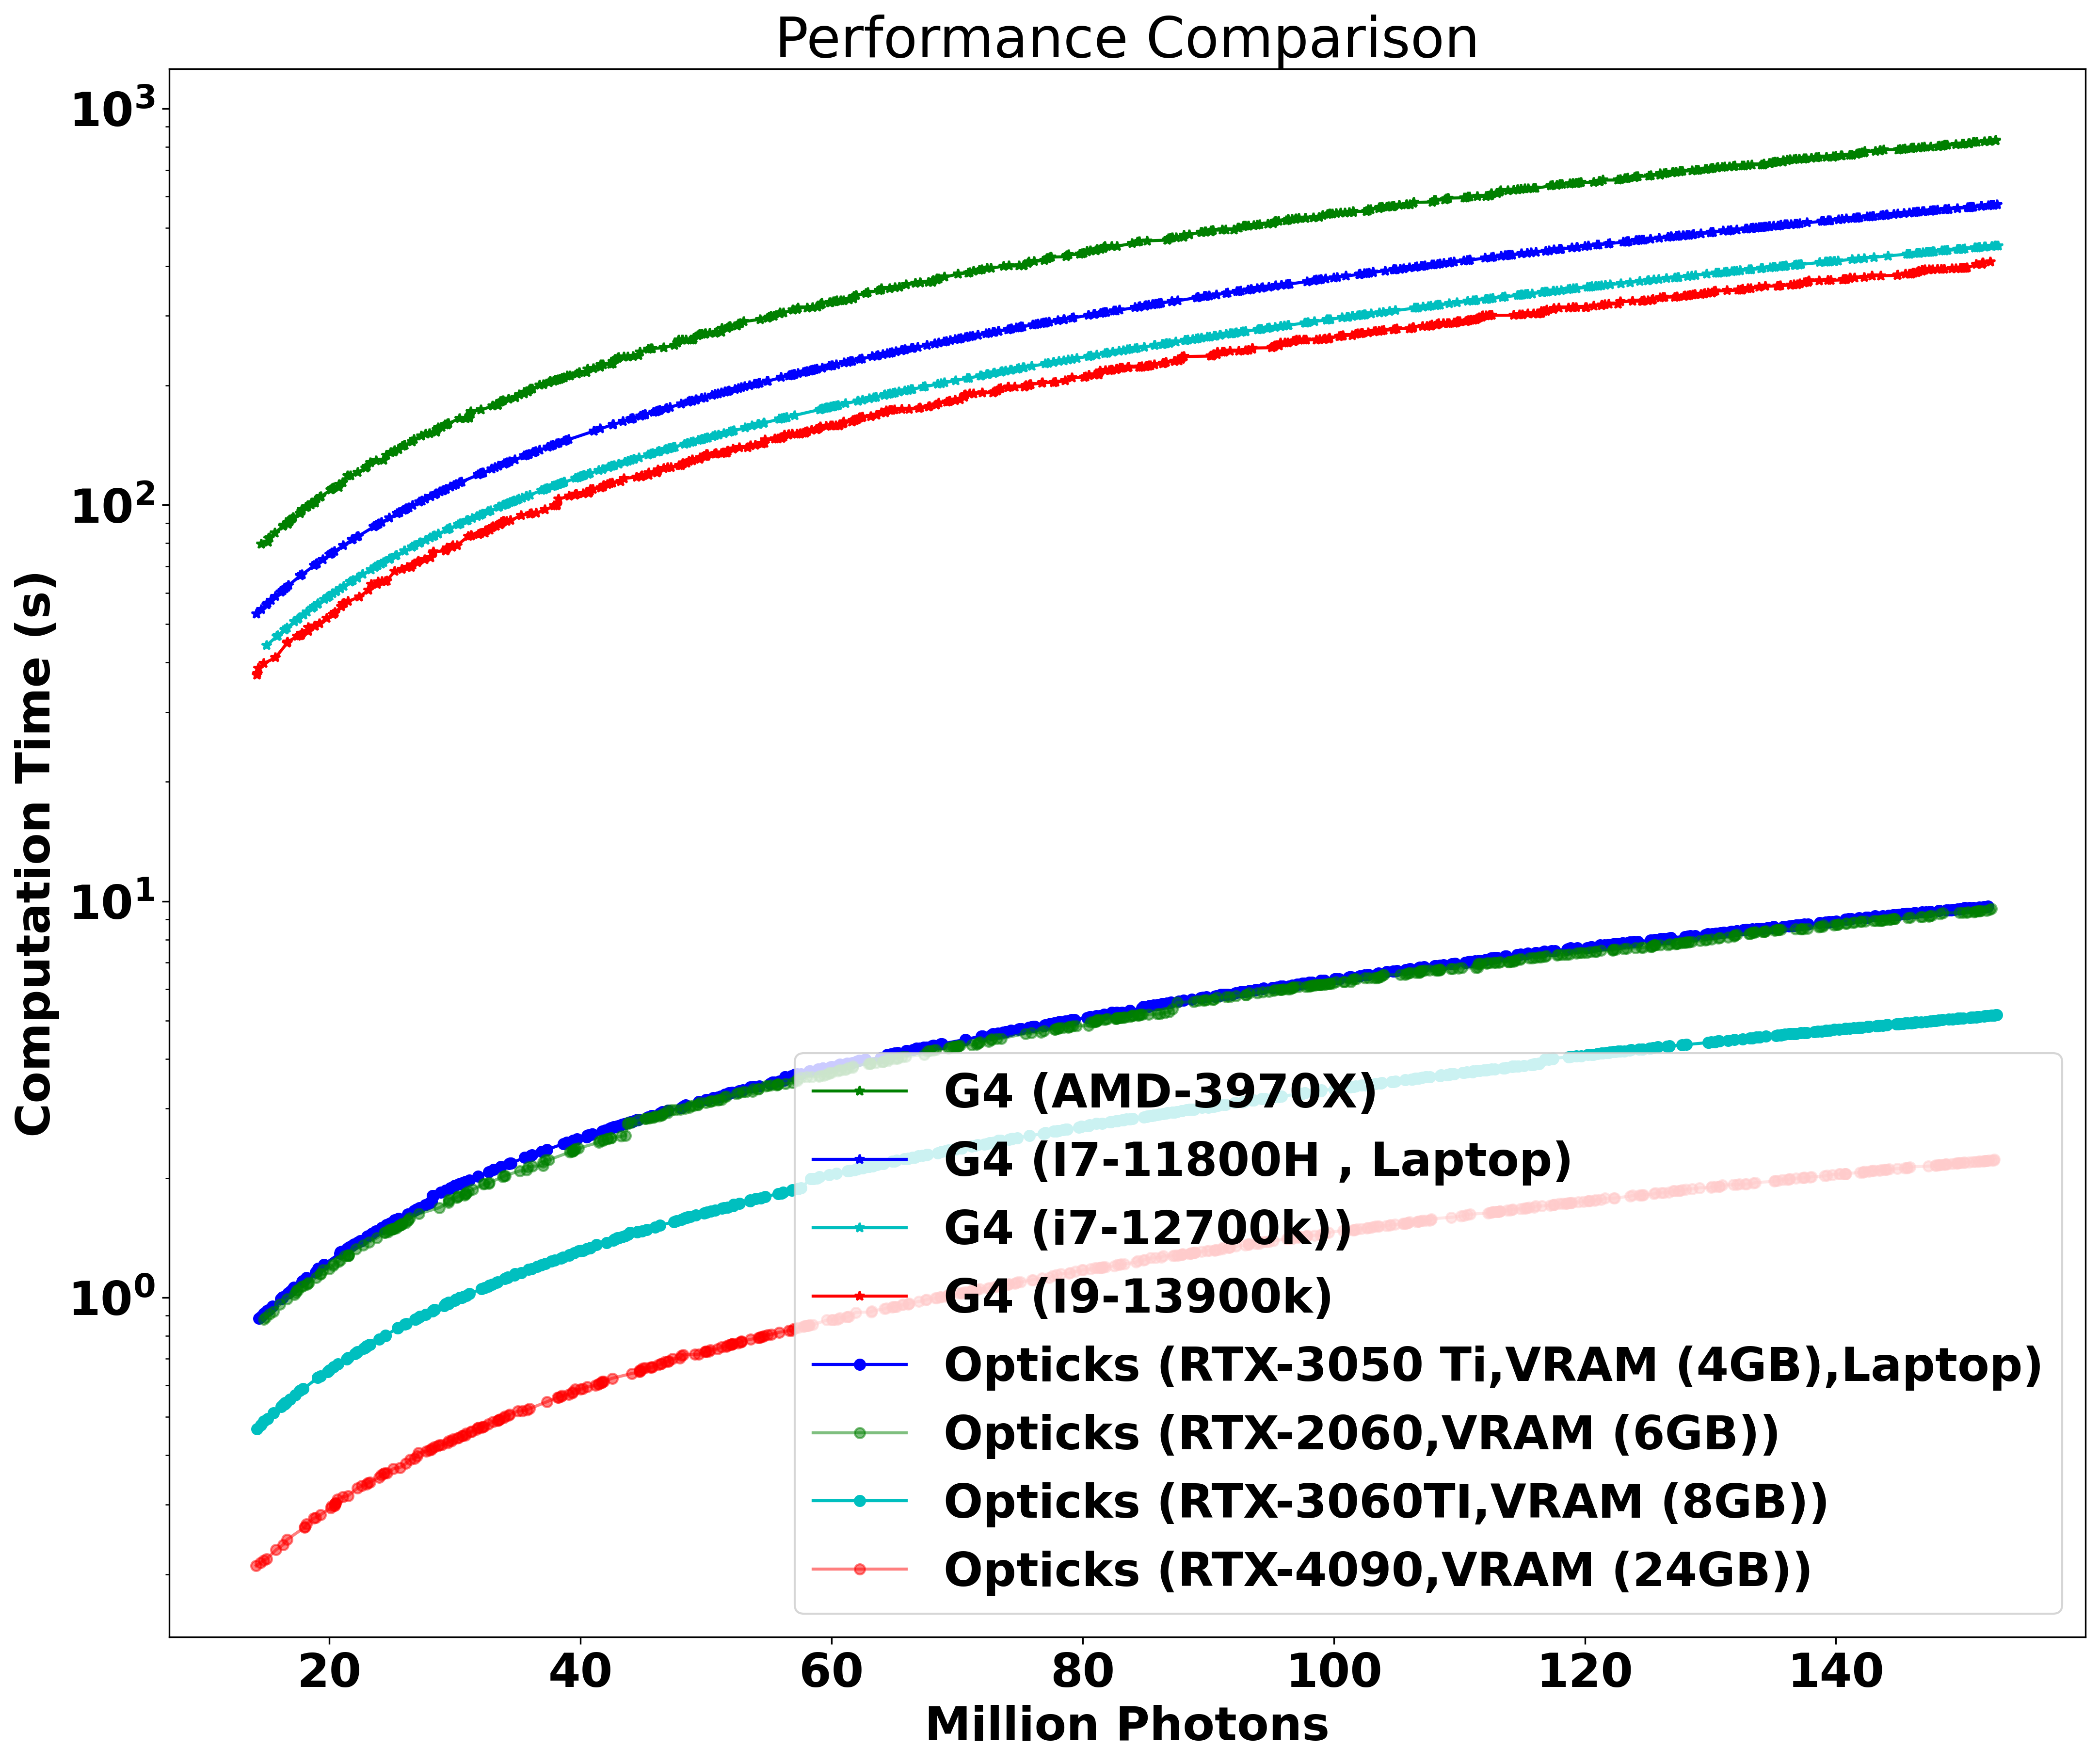

In [11]:
plt.figure(figsize=(17,14),dpi=300)
## G4
plt.plot(np.sort(ArgonTrx_G4["Timing"]["photons"]/1e6),np.sort(ArgonTrx_G4["Timing"]["time"]),label="G4 (AMD-3970X)",marker="*",markersize=5,color="green")
plt.plot(np.sort(Laptop_G4["Timing"]["photons"]/1e6),np.sort(Laptop_G4["Timing"]["time"]),label="G4 (I7-11800H , Laptop)",marker="*",markersize=5,color="blue")
plt.plot(np.sort(I72700K_["Timing"]["photons"]/1e6),np.sort(I72700K_["Timing"]["time"]),label="G4 (i7-12700k))",marker="*",markersize=5,color="c")
plt.plot(np.sort(run1G4["Timing"]["photons"]/1e6),np.sort(run1G4["Timing"]["time"]),label="G4 (I9-13900k)",marker="*",markersize=5,color="red")


## Opticks
plt.plot(np.sort(Laptop_Opticks["Timing"]["photons"]/1e6),np.sort(Laptop_Opticks["Timing"]["time"]),label="Opticks (RTX-3050 Ti,VRAM (4GB),Laptop)",marker="o",markersize=5,color="blue")
plt.plot(np.sort(ArgonTrx_Opticks["Timing"]["photons"]/1e6),np.sort(ArgonTrx_Opticks["Timing"]["time"]),label="Opticks (RTX-2060,VRAM (6GB))",marker="o",markersize=5,color="green",alpha=0.5)
plt.plot(np.sort(I72700K_3060Ti["Timing"]["photons"]/1e6),np.sort(I72700K_3060Ti["Timing"]["time"]),label="Opticks (RTX-3060TI,VRAM (8GB))",marker="o",markersize=5,color="c")
#plt.plot(np.sort(LowPhoton25k["Timing/photons"]/1e6),np.sort(LowPhoton25k["Timing/time"]),label="Opticks (RTX-4090 Ti-25K)",marker="o",markersize=5,color="black")
plt.plot(np.sort(run1["Timing"]["photons"]/1e6),np.sort(run1["Timing"]["time"]),label="Opticks (RTX-4090,VRAM (24GB))",marker="o",markersize=5,color="red",alpha=0.5)


plt.title("Performance Comparison")
plt.xlabel("Million Photons")
plt.ylabel("Computation Time (s)")
#plt.axvline(14,0,1000,color="blue")
plt.legend()
plt.semilogy()
if(isSafeFiles):
    plt.savefig(f"{SavePath}/Performance.png")

plt.show()


In [13]:
print(f' Max Photon {np.max(np.sort(run1["Timing"]["photons"]/1e6))}  and Min Photon {np.min(np.sort(run1["Timing"]["photons"]/1e6))}')
print(f' Max Time {np.max(np.sort(run1["Timing"]["time"]))}  and Min Time {np.min(np.sort(run1["Timing"]["time"]))}')

print("-----------------------------------------")
print(f'(G4) Max Photon {np.max(np.sort(run1G4["Timing"]["photons"]/1e6))}  and Min Photon {np.min(np.sort(run1G4["Timing"]["photons"]/1e6))}')
print(f'(G4) Max Time {np.max(np.sort(run1G4["Timing"]["time"]))}  and Min Time {np.min(np.sort(run1G4["Timing"]["time"]))}')

 Max Photon 152.599876  and Min Photon 14.162887
 Max Time 2.23272054  and Min Time 0.210341181
-----------------------------------------
(G4) Max Photon 152.310827  and Min Photon 14.22512
(G4) Max Time 410.444352002  and Min Time 37.208084442


In [14]:
def applypolyfit(x,y,deg=1,cov=False):
    Slope=[]
    Intercept=[]
    Error=[]
    for p in range(0,len(x)):
        if(cov):
            s,e=np.polyfit(x[p],y[p],deg,cov=cov)
            Slope.append(s[0])
            Intercept.append(s[1])
            Error.append(e)
        else:
            s,i=np.polyfit(x[p],y[p],deg,cov=cov)
            Slope.append(s)
            Intercept.append(i)
    if (cov):        
        return Slope,Intercept,Error
    else:
        return Slope,Intercept
def getStandarError(covs):
    StandarError=[]
    Counter=0
    for cov in covs:
        StandarError.append(np.sqrt(np.diag(cov)))
    return StandarError    
def LinePLot(x,m,i):
    y=m*x+i
    return y
## sort the array and scale photons by million
def sortAndDataFrame(Time,Photon,name,type):
    sorted_indices=Time.argsort()
    Result={"Million Photons":Photon[sorted_indices]/1e6,"Computation Time(s)":Time[sorted_indices],"Device Name":name,"Type":type}
    Result['tmean']=np.mean(Result["Computation Time(s)"])
    Result['tstd']=np.std(Result["Computation Time(s)"])
    Result['tmedian']=np.median(Result["Computation Time(s)"])
    Result['tmax']=np.max(Result["Computation Time(s)"])
    Result['tmin']=np.min(Result["Computation Time(s)"])
    
    Result['pmean']=np.mean(Result["Million Photons"])
    Result['pstd']=np.std(Result["Million Photons"])
    Result['pmedian']=np.median(Result["Million Photons"])
    Result['pmax']=np.max(Result["Million Photons"])
    Result['pmin']=np.min(Result["Million Photons"])
    slope,intercept=np.polyfit(Result["Million Photons"],Result["Computation Time(s)"],1)
    Result["slope"]=slope
    Result["intercept"]=intercept
    return Result        


ArgonTrxSortedG4 = sortAndDataFrame(ArgonTrx_G4["Timing"]["time"],ArgonTrx_G4["Timing"]["photons"],'AMD-3970X','G4')
LaptopSorted_G4=sortAndDataFrame(Laptop_G4["Timing"]["time"],Laptop_G4["Timing"]["photons"],'i7-11800H,Laptop','G4')
I72700KSorted_G4=sortAndDataFrame(I72700K_["Timing"]["time"],I72700K_["Timing"]["photons"],'i7-12700k','G4')
I913900_G4=sortAndDataFrame(run1G4["Timing"]["time"],run1G4["Timing"]["photons"],'i9-13900k','G4')
### GPU
ArgonTrxSortedOpticks = sortAndDataFrame(ArgonTrx_Opticks["Timing"]["time"],ArgonTrx_Opticks["Timing"]["photons"],'RTX-2060,VRAM (6GB)','Opticks')
LaptopSorted_Opticks=sortAndDataFrame(Laptop_Opticks["Timing"]["time"],Laptop_Opticks["Timing"]["photons"],'RTX-3050 Ti,VRAM (4GB),Laptop','Opticks')
I72700KSorted_Opticks=sortAndDataFrame(I72700K_3060Ti["Timing"]["time"],I72700K_3060Ti["Timing"]["photons"],'RTX-3060TI,VRAM (8GB)','Opticks')
I913900Sorted_Opticks=sortAndDataFrame(run1["Timing"]["time"],run1["Timing"]["photons"],'RTX-4090,VRAM (24GB)','Opticks')

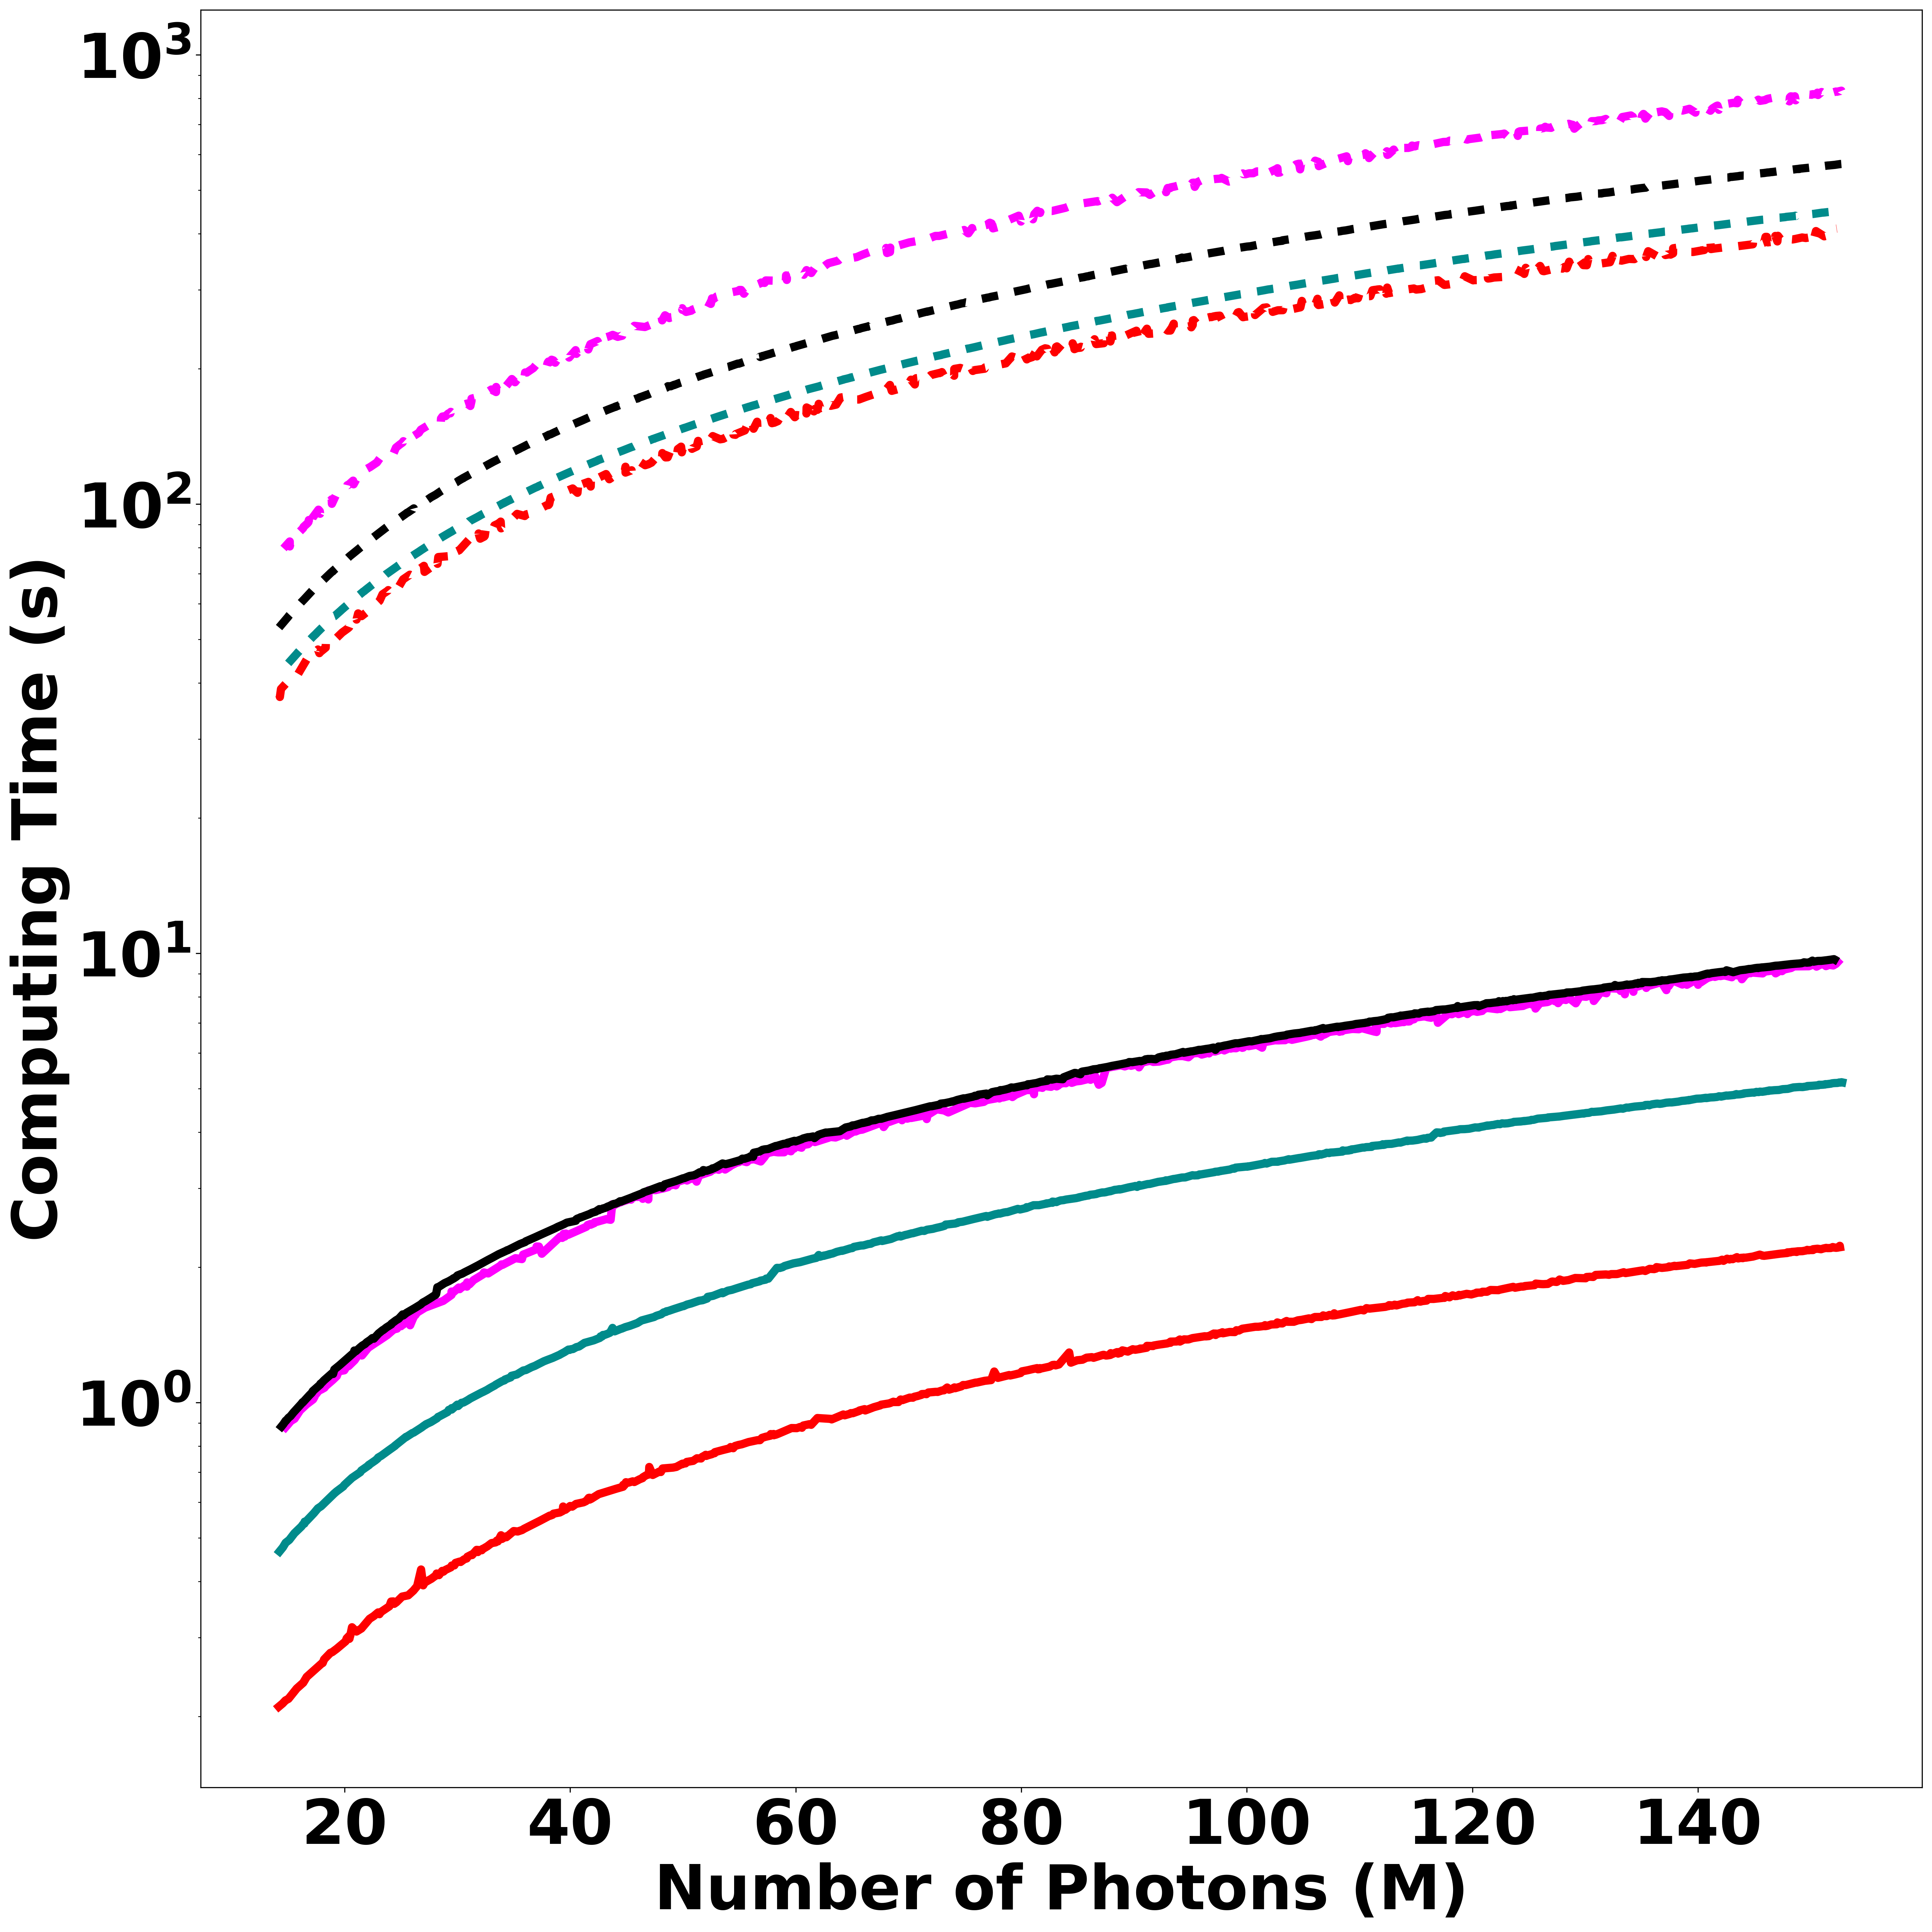

In [25]:
import seaborn as sns
## Lets Sort the arrays so that we dnt get weird behaviors
## CPUS 
ArgonTrxSortedG4 = sortAndDataFrame(ArgonTrx_G4["Timing"]["time"],ArgonTrx_G4["Timing"]["photons"],'AMD-3970X','G4')
LaptopSorted_G4=sortAndDataFrame(Laptop_G4["Timing"]["time"],Laptop_G4["Timing"]["photons"],'i7-11800H','G4')
I72700KSorted_G4=sortAndDataFrame(I72700K_["Timing"]["time"],I72700K_["Timing"]["photons"],'i7-12700k','G4')
I913900_G4=sortAndDataFrame(run1G4["Timing"]["time"],run1G4["Timing"]["photons"],'i9-13900k','G4')
### GPU
ArgonTrxSortedOpticks = sortAndDataFrame(ArgonTrx_Opticks["Timing"]["time"],ArgonTrx_Opticks["Timing"]["photons"],'RTX-2060','Opticks')
LaptopSorted_Opticks=sortAndDataFrame(Laptop_Opticks["Timing"]["time"],Laptop_Opticks["Timing"]["photons"],'RTX-3050 TI Mobile','Opticks')
I72700KSorted_Opticks=sortAndDataFrame(I72700K_3060Ti["Timing"]["time"],I72700K_3060Ti["Timing"]["photons"],'RTX-3060TI','Opticks')
I913900Sorted_Opticks=sortAndDataFrame(run1["Timing"]["time"],run1["Timing"]["photons"],'RTX-4090','Opticks')
opacity=1                          
plt.figure(figsize=(20,20),dpi=300)
sns.lineplot(data=ArgonTrxSortedG4, x="Million Photons", y="Computation Time(s)",hue="Device Name",palette=['magenta'],linewidth=6,alpha=opacity,dashes=(2,2),legend=False)
#sns.lineplot(x=ArgonTrxSortedG4["Million Photons"], y=LinePLot(ArgonTrxSortedG4["Million Photons"], ArgonTrxSortedG4["slope"], ArgonTrxSortedG4["intercept"]),color='green', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=LaptopSorted_G4, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["black"],linewidth=6,alpha=opacity,dashes=[(2, 2)],legend=False)

#sns.lineplot(x=LaptopSorted_G4["Million Photons"], y=LinePLot(LaptopSorted_G4["Million Photons"], LaptopSorted_G4["slope"], LaptopSorted_G4["intercept"]),color='blue', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=I72700KSorted_G4, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["darkcyan"],linewidth=6,alpha=opacity,dashes=[(2, 2)],legend=False)
#sns.lineplot(x=I72700KSorted_G4["Million Photons"], y=LinePLot(I72700KSorted_G4["Million Photons"], I72700KSorted_G4["slope"], I72700KSorted_G4["intercept"]),color='c', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=I913900_G4, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["red"],linewidth=6,alpha=opacity,dashes=[(2, 2)],legend=False)

#sns.lineplot(x=I913900_G4["Million Photons"], y=LinePLot(I913900_G4["Million Photons"], I913900_G4["slope"], I913900_G4["intercept"]),color='red', linewidth=6, linestyle='dashed',alpha=0.4,)
sns.lineplot(data=ArgonTrxSortedOpticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["magenta"],linewidth=6,alpha=opacity,legend=False)
#sns.lineplot(x=ArgonTrxSortedOpticks["Million Photons"], y=LinePLot(ArgonTrxSortedOpticks["Million Photons"], ArgonTrxSortedOpticks["slope"], ArgonTrxSortedOpticks["intercept"]),color='green', linewidth=6, linestyle='dashed',alpha=0.4)

sns.lineplot(data=LaptopSorted_Opticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["black"],linewidth=6,alpha=opacity,legend=False)
#sns.lineplot(x=LaptopSorted_Opticks["Million Photons"], y=LinePLot(LaptopSorted_Opticks["Million Photons"], LaptopSorted_Opticks["slope"], LaptopSorted_Opticks["intercept"]),color='blue', linewidth=6, linestyle='dashed',alpha=0.4)
sns.lineplot(data=I72700KSorted_Opticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["darkcyan"],linewidth=6,alpha=opacity,legend=False)
#sns.lineplot(x=I72700KSorted_Opticks["Million Photons"], y=LinePLot(I72700KSorted_Opticks["Million Photons"], I72700KSorted_Opticks["slope"], I72700KSorted_Opticks["intercept"]),color='c', linewidth=6, linestyle='dashed',alpha=0.4)
sns.lineplot(data=I913900Sorted_Opticks, x="Million Photons", y="Computation Time(s)", hue="Device Name",style="Device Name",palette=["red"],linewidth=6,alpha=opacity,legend=False)
#sns.lineplot(x=I913900Sorted_Opticks["Million Photons"], y=LinePLot(I913900Sorted_Opticks["Million Photons"], I913900Sorted_Opticks["slope"], I913900Sorted_Opticks["intercept"]),color='red', linewidth=6, linestyle='dashed',alpha=0.4)

Labels=[ArgonTrxSortedG4["Device Name"]+"/"+ArgonTrxSortedOpticks["Device Name"],'_',   LaptopSorted_G4["Device Name"]+"/"+LaptopSorted_Opticks["Device Name"],'_',
I72700KSorted_G4["Device Name"]+"/"+I72700KSorted_Opticks["Device Name"],'_',
I913900_G4["Device Name"]+"/"+I913900Sorted_Opticks["Device Name"],'_']
#plt.suptitle("Performance Comparison",fontweight='bold',y=0.95,fontsize=40)
plt.xlabel("Number of Photons (M)",fontweight='bold',y=0.95,fontsize=45)
plt.ylabel("Computing Time (s)",fontweight='bold',fontsize=45)
#plt.legend(title="Device Names",loc="lower right",labels=Labels,fontsize=35)
plt.xticks(fontsize=45)
plt.yticks(fontsize=45)

plt.semilogy()
plt.tight_layout()

#plt.savefig(f"{SavePath}/Performance.png")
plt.show()


In [16]:

                          
plt.figure(figsize=(25,25),dpi=300)
plt.plot(ArgonTrxSortedG4["Million Photons"], ArgonTrxSortedG4["Computation Time(s)"], label=ArgonTrxSortedG4["Device Name"],color='green',linewidth=6,alpha=1,linestyle='dotted',marker="o")
#sns.lineplot(x=ArgonTrxSortedG4["Million Photons"], y=LinePLot(ArgonTrxSortedG4["Million Photons"], ArgonTrxSortedG4["slope"], ArgonTrxSortedG4["intercept"]),color='green', linewidth=6, linestyle='dashed',alpha=0.4,)

plt.plot(LaptopSorted_G4["Million Photons"], LaptopSorted_G4["Computation Time(s)"], label=LaptopSorted_G4["Device Name"],color='blue',linewidth=6,alpha=1,linestyle='dotted',marker="o")
#sns.lineplot(x=LaptopSorted_G4["Million Photons"], y=LinePLot(LaptopSorted_G4["Million Photons"], LaptopSorted_G4["slope"], LaptopSorted_G4["intercept"]),color='blue', linewidth=6, linestyle='dashed',alpha=0.4,)
plt.plot(I72700KSorted_G4["Million Photons"], I72700KSorted_G4["Computation Time(s)"], label=I72700KSorted_G4["Device Name"],color='c',linewidth=6,alpha=1,linestyle='dotted',marker="o")

#sns.lineplot(x=I72700KSorted_G4["Million Photons"], y=LinePLot(I72700KSorted_G4["Million Photons"], I72700KSorted_G4["slope"], I72700KSorted_G4["intercept"]),color='c', linewidth=6, linestyle='dashed',alpha=0.4,)

plt.plot(I913900_G4["Million Photons"], I913900_G4["Computation Time(s)"], label=I913900_G4["Device Name"],color='red',linewidth=6,alpha=1,linestyle='dotted',marker="o")

#sns.lineplot(x=I913900_G4["Million Photons"], y=LinePLot(I913900_G4["Million Photons"], I913900_G4["slope"], I913900_G4["intercept"]),color='red', linewidth=6, linestyle='dashed',alpha=0.4,)

plt.plot(ArgonTrxSortedOpticks["Million Photons"], ArgonTrxSortedOpticks["Computation Time(s)"], label=ArgonTrxSortedOpticks["Device Name"],color='green',linewidth=6,alpha=1,marker="*")
#sns.lineplot(x=ArgonTrxSortedOpticks["Million Photons"], y=LinePLot(ArgonTrxSortedOpticks["Million Photons"], ArgonTrxSortedOpticks["slope"], ArgonTrxSortedOpticks["intercept"]),color='green', linewidth=6, linestyle='dashed',alpha=0.4)

plt.plot(LaptopSorted_Opticks["Million Photons"], LaptopSorted_Opticks["Computation Time(s)"], label=LaptopSorted_Opticks["Device Name"],color='blue',linewidth=6,alpha=1,marker="*")
#sns.lineplot(x=LaptopSorted_Opticks["Million Photons"], y=LinePLot(LaptopSorted_Opticks["Million Photons"], LaptopSorted_Opticks["slope"], LaptopSorted_Opticks["intercept"]),color='blue', linewidth=6, linestyle='dashed',alpha=0.4)

plt.plot(I72700KSorted_Opticks["Million Photons"], I72700KSorted_Opticks["Computation Time(s)"], label=I72700KSorted_Opticks["Device Name"],color='c',linewidth=6,alpha=1,marker="*")
#sns.lineplot(x=I72700KSorted_Opticks["Million Photons"], y=LinePLot(I72700KSorted_Opticks["Million Photons"], I72700KSorted_Opticks["slope"], I72700KSorted_Opticks["intercept"]),color='c', linewidth=6, linestyle='dashed',alpha=0.4)

plt.plot(I913900Sorted_Opticks["Million Photons"], I913900Sorted_Opticks["Computation Time(s)"], label=I913900Sorted_Opticks["Device Name"],color='red',linewidth=6,alpha=1,marker="*")
#sns.lineplot(x=I913900Sorted_Opticks["Million Photons"], y=LinePLot(I913900Sorted_Opticks["Million Photons"], I913900Sorted_Opticks["slope"], I913900Sorted_Opticks["intercept"]),color='red', linewidth=6, linestyle='dashed',alpha=0.4)
plt.suptitle("Performance Comparison",fontweight='bold',y=0.95,fontsize=40)
plt.xlabel("Number of Photons (M)",fontweight='bold',y=0.95,fontsize=35)
plt.ylabel("Computation Time (s)",fontweight='bold',fontsize=35)

plt.legend()
plt.semilogy()
plt.tight_layout()

#plt.savefig(f"{SavePath}/Performance.png")
plt.show(block=False)


In [16]:
newdf=pd.DataFrame([ArgonTrxSortedG4, I72700KSorted_G4,LaptopSorted_G4,I913900_G4,ArgonTrxSortedOpticks,LaptopSorted_Opticks,I72700KSorted_Opticks,I913900Sorted_Opticks])

In [17]:
newdf['tmean']=newdf["Computation Time(s)"].apply(np.mean)
newdf['tstd']=newdf["Computation Time(s)"].apply(np.std)
newdf['tmedian']=newdf["Computation Time(s)"].apply(np.median)
newdf['tmax']=newdf["Computation Time(s)"].apply(np.max)
newdf['tmin']=newdf["Computation Time(s)"].apply(np.min)

newdf['pmean']=newdf["Million Photons"].apply(np.mean)
newdf['pstd']=newdf["Million Photons"].apply(np.std)
newdf['pmedian']=newdf["Million Photons"].apply(np.median)
newdf['pmax']=newdf["Million Photons"].apply(np.max)
newdf['pmin']=newdf["Million Photons"].apply(np.min)
slope,intercept,cov=applypolyfit(newdf["Million Photons"],newdf["Computation Time(s)"],deg=1,cov=True)
newdf["slope"]=slope
newdf["intercept"]=intercept
newdf["cov"]=cov
newdf["standarError"]=getStandarError(cov)

In [18]:
print(newdf["standarError"])

0        [0.005001009378260349, 0.46472352185966875]
1      [8.287503344826612e-05, 0.007502382801841402]
2     [0.00024708737147398146, 0.023112969567028154]
3        [0.0038602143317220095, 0.3501821119056411]
4      [7.486063961524462e-05, 0.006904388217028318]
5    [2.0537652067349562e-05, 0.0019181779372293884]
6     [2.315398437786604e-05, 0.0021945998832405148]
7    [6.3453132084585935e-06, 0.0005924063238698067]
Name: standarError, dtype: object


In [19]:
Stats=newdf.drop("Million Photons",axis=1)
Stats=Stats.drop("Computation Time(s)",axis=1)

SlopeData=pd.DataFrame({"Device Name":Stats["Device Name"],"Type":Stats["Type"],"Slope":Stats["slope"],"intercept":Stats["intercept"],"err":Stats["standarError"]})


In [26]:
RelativePercentDiff = lambda v1,v2:abs(v1-v2)/abs(np.mean([v1,v2]))*100
Absolute = lambda v1,v2:abs(v1-v2)
Ratio = lambda v1,v2:(v1/v2)
Rrnd = lambda v:round(v,3)
def GetPercents(Data,IndexC,IndexG):
    CPU=Data.iloc[IndexC[0]:IndexC[1]]
    GPU=Data.iloc[IndexG[0]:IndexG[1]]
    CSlope=CPU["Slope"][IndexC[0]]
    GSlope=GPU["Slope"][IndexG[0]]
    ErrCSlope=CPU["err"][IndexC[0]][0]
    ErrGSlope=GPU["err"][IndexG[0]][0]
   
    Error=np.sqrt((ErrCSlope/CSlope)**2+(ErrGSlope/GSlope)**2)
    
    RelativeDifference=RelativePercentDiff(CSlope,GSlope)
    AbsoluteDifference=Absolute(CSlope,GSlope)
    RatioDifference=Ratio(CSlope,GSlope)
    #pintercept=RelativePercentDiff(CPU["intercept"][IndexC[0]],GPU["intercept"][IndexG[0]])
    #ErrorOnIntercept=pintercept*np.sqrt((CPU["err"][IndexC[0]][1]/CPU["intercept"][IndexC[0]])**2+(GPU["err"][IndexG[0]][1]/GPU["intercept"][IndexG[0]])**2)
  
    dict=pd.DataFrame([{"D Name":f"{CPU['Device Name'][IndexC[0]]}/{GPU['Device Name'][IndexG[0]]}",
                       "RP Difference (%)":[Rrnd(RelativeDifference),Rrnd(Error*RelativeDifference)],"Absolute Difference ":[Rrnd(AbsoluteDifference),Rrnd(AbsoluteDifference*Error)],"Ratio (%)":[Rrnd(RatioDifference),Rrnd(RatioDifference*Error)]}])
    print(dict)
    return dict
    

In [27]:
SlopeData.iloc[4:5]

,Device Name,Type,Slope,intercept,err
4,RTX-2060,Opticks,0.062664,-0.072483,"[7.486063961524462e-05, 0.006904388217028318]"


In [28]:
SlopeData

,Device Name,Type,Slope,intercept,err
0,AMD-3970X,G4,5.430801,-0.590158,"[0.005001009378260349, 0.46472352185966875]"
1,i7-12700k,G4,2.947012,0.008922,"[8.287503344826612e-05, 0.007502382801841402]"
2,i7-11800H,G4,3.741559,0.024837,"[0.00024708737147398146, 0.023112969567028154]"
3,i9-13900k,G4,2.639383,0.434629,"[0.0038602143317220095, 0.3501821119056411]"
4,RTX-2060,Opticks,0.062664,-0.072483,"[7.486063961524462e-05, 0.006904388217028318]"
5,RTX-3050 TI Mobile,Opticks,0.063987,-0.037711,"[2.0537652067349562e-05, 0.0019181779372293884]"
6,RTX-3060TI,Opticks,0.034061,-0.036331,"[2.315398437786604e-05, 0.0021945998832405148]"
7,RTX-4090,Opticks,0.014551,0.003818,"[6.3453132084585935e-06, 0.0005924063238698067]"


In [31]:

ArgonMachinePercent=GetPercents(SlopeData,IndexC=[0,1],IndexG=[4,5])
laptopPercent=GetPercents(SlopeData,IndexC=[2,3],IndexG=[5,6])
RTX4090Percent = GetPercents(SlopeData, IndexC=[3, 4], IndexG=[7, 8])
RTX3060TiPercent = GetPercents(SlopeData, IndexC=[1, 2], IndexG=[6, 7])
All=[ArgonMachinePercent,RTX4090Percent,RTX3060TiPercent,laptopPercent]

               D Name RP Difference (%) Absolute Difference         Ratio (%)
0  AMD-3970X/RTX-2060  [195.437, 0.295]       [5.368, 0.008]  [86.666, 0.131]
                         D Name RP Difference (%) Absolute Difference   \
0  i7-11800H/RTX-3050 TI Mobile  [193.274, 0.063]       [3.678, 0.001]   

         Ratio (%)  
0  [58.474, 0.019]  
               D Name RP Difference (%) Absolute Difference          Ratio (%)
0  i9-13900k/RTX-4090  [197.807, 0.302]       [2.625, 0.004]  [181.385, 0.277]
                 D Name RP Difference (%) Absolute Difference   \
0  i7-12700k/RTX-3060TI   [195.43, 0.133]       [2.913, 0.002]   

         Ratio (%)  
0  [86.522, 0.059]  


In [34]:
from tabulate import tabulate
table=tabulate(All,headers='keys')
print(table)

D Name                             RP Difference (%)                       Absolute Difference                        Ratio (%)
---------------------------------  --------------------------------------  -----------------------------------------  ------------------------------
0    AMD-3970X/RTX-2060            0    [195.437, 0.295]                   0    [5.368, 0.008]                        0    [86.666, 0.131]
Name: D Name, dtype: object        Name: RP Difference (%), dtype: object  Name: Absolute Difference , dtype: object  Name: Ratio (%), dtype: object
0    i9-13900k/RTX-4090            0    [197.807, 0.302]                   0    [2.625, 0.004]                        0    [181.385, 0.277]
Name: D Name, dtype: object        Name: RP Difference (%), dtype: object  Name: Absolute Difference , dtype: object  Name: Ratio (%), dtype: object
0    i7-12700k/RTX-3060TI          0    [195.43, 0.133]                    0    [2.913, 0.002]                        0    [86.522, 0.059]
Name: D

In [25]:
### worst device 
G4Slope=float (Stats[Stats["Device Name"]=="i9-13900k"]["slope"])
OSlope=float (Stats[Stats["Device Name"]=="RTX-3050 Ti,VRAM (4GB),Laptop"]["slope"])
Speed=G4Slope/OSlope
print(Speed)
G4Slope=float (Stats[Stats["Device Name"]=="AMD-3970X"]["slope"])
OSlope=float (Stats[Stats["Device Name"]=="RTX-4090,VRAM (24GB)"]["slope"])
Speed=G4Slope/OSlope
print(Speed)

TypeError: cannot convert the series to <class 'float'>

In [ ]:
Stats

In [ ]:
Stats[Stats["Device Name"]==ArgonTrxSortedG4["Device Name"]][["slope","intercept"]]

In [ ]:
Values=Stats[Stats["Device Name"]==ArgonTrxSortedG4["Device Name"]][["slope","intercept"]]
LinePLot(ArgonTrxSortedG4["Million Photons"],Values["slope"][0],Values["intercept"][0])

In [ ]:
sns.lineplot(data=ArgonTrxSortedG4, x="Million Photons", y="Computation Time(s)", hue="Device Name",palette=['green'],linewidth=4,alpha=0.4)
sns.lineplot(x=ArgonTrxSortedG4["Million Photons"],y=LinePLot(ArgonTrxSortedG4["Million Photons"],ArgonTrxSortedG4["slope"],ArgonTrxSortedG4["intercept"]),color='green',linewidth=4,linestyle='dashed',alpha=0.4)
plt.semilogy()

In [ ]:
### GEANT4 AND OPTICKS SIMULATED AT THE SAME TIME
OpticksG4Test=GetInfo("/home/argon/Projects/Ilker/NewNexus/output/Opticks_Hit_Comparison/G4Opticks_172nm.h5")["MC"]

In [ ]:
Test1=EventSummary("Opticks_Hits",2,OpticksG4Test,boundaries=[30,31])
Test1_G4=EventSummary("GEANT4_Optical_Hits",2,OpticksG4Test,det=[b'camWindow',b'PMTWindow'])


f, (ax1, ax2) = plt.subplots(1, 2,figsize=(15,12), sharey=True,sharex=True)

ax1.set_title("Opticks")
_=ax1.hist2d(Test1[1][0],Test1[1][1],bins=100,cmap="hot")
ax2.set_title("GEANT4")
_=ax2.hist2d(Test1_G4[1][0],Test1_G4[1][1],bins=100,cmap="hot")
plt.subplots_adjust(wspace=0.2, hspace=0.1)


In [ ]:
#### Wavelenghth Comparison
G4=OpticksG4Test["GEANT4_Optical_Hits"]
Opticks=OpticksG4Test["Opticks_Hits"]
wMax=np.max(np.array([np.max(G4["wavelength"]),np.max(Opticks["wavelength"])]))
wMin=np.min(np.array([np.min(G4["wavelength"]),np.min(Opticks["wavelength"])]))

bins_=np.linspace(wMin,wMax,100)
plt.title("Wavelength of Detected Photons")
plt.hist(Opticks["wavelength"],bins=bins_,alpha=1,label="Opticks",color="red",edgecolor="black")
plt.hist(G4["wavelength"],bins=bins_,alpha=0.5,label="G4",hatch='//',color="green",edgecolor="green")
plt.xlabel("wavelength (nm)")
plt.legend()
if(isSafeFiles):
    plt.savefig(f"{SavePath}/Wavelength.png")
plt.show()

In [ ]:

wMax=np.max(np.array([np.max(G4["time"]),np.max(Opticks["time"])]))
wMin=np.min(np.array([np.min(G4["time"]),np.min(Opticks["time"])]))

bins_=np.linspace(wMin,wMax,100)
#plt.figure(figsize=(15,12),dpi=300)
plt.title("Time of Arrival of Detected Photons")
plt.hist(Opticks["time"],bins=bins_,alpha=1,label="Opticks",color="red",edgecolor="black")
plt.hist(G4["time"],bins=bins_,alpha=0.5,label="G4",hatch='//',color="green",edgecolor="green")
xticks_=np.linspace(wMin,wMax,6)
print(xticks_)
plt.xticks(xticks_)
plt.xlabel("Time of Arrival (ns)")
plt.legend()
if(isSafeFiles):
    plt.savefig(f"{SavePath}/TOA.png")
plt.show()

In [ ]:
## S1 and S2 Seperately
## S1
MaskG4_=G4["time"]<2000
MaskOpticks_=Opticks["time"]<2000
wMax_=np.max(np.array([np.max(G4["time"][MaskG4_]),np.max(Opticks["time"][MaskOpticks_])]))
wMin_=np.min(np.array([np.min(G4["time"][MaskG4_]),np.min(Opticks["time"][MaskOpticks_])]))

bins_=np.linspace(wMin_,wMax_,100)
#plt.figure(figsize=(15,12),dpi=300)
#plt.title("Time of Arrival of Detected Photons")
f,ax=plt.subplots(1,2,figsize=(15,15),sharey=False,sharex=False)
ax[0].set_title("S1")
ax[0].hist(Opticks["time"][MaskOpticks_],bins=bins_,alpha=1,label="Opticks",color="red",edgecolor="black")
ax[0].hist(G4["time"][MaskG4_],bins=bins_,alpha=0.5,label="G4",hatch='//',color="green",edgecolor="green")
print(f"S1 Min {wMin_}, Max {wMax_}")
ax[0].set_xlabel("Time of Arrival (ns)")


ax[0].set_xlim(wMin_,wMax_)
ax[0].legend()
## S2
MaskG4=G4["time"]>5000
MaskOpticks=Opticks["time"]>5000
wMax=np.max(np.array([np.max(G4["time"][MaskG4]),np.max(Opticks["time"][MaskOpticks])]))
wMin=np.min(np.array([np.min(G4["time"][MaskG4]),np.min(Opticks["time"][MaskOpticks])]))
print(f"S2 Min {wMin}, Max {wMax}")
bins_=np.linspace(wMin,wMax,100)
ax[1].set_title("S2")
ax[1].hist(Opticks["time"][MaskOpticks],bins=bins_,alpha=1,label="Opticks",color="red",edgecolor="black")
ax[1].hist(G4["time"][MaskG4],bins=bins_,alpha=0.5,label="G4",hatch='//',color="green",edgecolor="green")
ax[1].set_xlim(wMin,wMax)
xticks_=np.linspace(wMin,wMax,4)
ax[1].set_xticks(xticks_)
ax[1].legend()
ax[1].set_xlabel("Time of Arrival (ns)")

if(isSafeFiles):
    plt.savefig(f"{SavePath}/TOA.png")
plt.show()


In [ ]:
### This is reading .txt files
def PerformanceInfo(Path):
    with open(Path,"r") as f:
        lines=f.readlines()
        
    Time=np.array([])
    Photons=np.array([])
    for line in lines:
    
        splited=line.split(",")
        if(splited[0]=="EventID"):
            continue
        Time=np.append(Time,float(splited[1].strip()))
        Photons=np.append(Photons,int(splited[2].strip()))
    return Time,Photons    

In [ ]:
G4Hit=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/G4/GEANT4HitComparison/CRAB/jobid_1/runhit.h5")

In [ ]:
print(G4Hit)

In [ ]:
### HIT Study

run1HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/Opticks_Test.h5")
#run2HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run2.h5")
#run3HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run3.h5")
#run1HitOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/HitRuns/Opticks/run1.h5")



In [ ]:
import numpy as np


Opticks=EventSummary("Opticks_Hits",2,run1HitOpticks)
G4=EventSummary("GEANT4_Optical_Hits",2,G4Hit)

AveragedOpticks={"PMTX":np.array([]),"PMTY":np.array([]),"CamX":np.array([]),"CamY":np.array([])}
AveragedG4={"PMTX":np.array([]),"PMTY":np.array([]),"CamX":np.array([]),"CamY":np.array([])}
for i in range(0,10):
    Opticks=EventSummary("Opticks_Hits",i,run1HitOpticks)
    G4=EventSummary("GEANT4_Optical_Hits",i,G4Hit)
    AveragedOpticks["PMTX"]=np.append(AveragedOpticks["PMTX"],Opticks[1][0])
    AveragedOpticks["PMTY"]=np.append(AveragedOpticks["PMTY"],Opticks[1][1])
    AveragedOpticks["CamX"]=np.append(AveragedOpticks["CamX"],Opticks[2][0])
    AveragedOpticks["CamY"]=np.append(AveragedOpticks["CamY"],Opticks[2][1])
    AveragedG4["PMTX"]=np.append(AveragedG4["PMTX"],G4[1][0])
    AveragedG4["PMTY"]=np.append(AveragedG4["PMTY"],G4[1][1])
    AveragedG4["CamX"]=np.append(AveragedG4["CamX"],G4[2][0])
    AveragedG4["CamY"]=np.append(AveragedG4["CamY"],G4[2][1])

    


In [ ]:
f,ax = plt.subplots(2, 2, sharey=True,figsize=(15,15))

binns=[np.linspace(-11,11,100),np.linspace(-11,11,100)]
_=ax[0,0].hist2d(AveragedOpticks["PMTX"], AveragedOpticks["PMTY"],bins=binns ,label="Opticks",density=True)
ax[0,0].set_title("Anode Window (Opticks)")
ax[0,0].set_ylabel("(mm)")

ax[0,1].set_title("Anode Window (G4)")
_=ax[0,1].hist2d(AveragedG4["PMTX"], AveragedG4["PMTY"],bins=binns,label="G4")
ax[1,0].set_ylabel("(mm)")

ax[1,0].set_title("Cathode Window (Opticks)")
ax[1,1].set_title("Cathode Window (G4)")
_=ax[1,0].hist2d(AveragedOpticks["CamX"],AveragedOpticks["CamY"],bins=binns ,label="Opticks")

_=ax[1,1].hist2d(AveragedG4["CamX"], AveragedG4["CamY"],bins=binns,label="G4")
plt.subplots_adjust(wspace=0, hspace=0.1)

In [ ]:
G4HitRun=[G4Hit]

In [ ]:
#G4Hits=GetDistributions(G4HitRun,"GEANT4_Optical_Hits")

In [ ]:
print(TestRun)

In [ ]:
testOpticks=GetInfo("/home/argon/Projects/Ilker/NewNexus/Opticks_Testv2.h5")
test=GetInfo("/home/argon/Projects/Ilker/NewNexus/G4_Test.h5")

In [ ]:
import matplotlib as mpl
import matplotlib.cm as cm
Event=3
Test1=EventSummary("Opticks_Hits",Event,testOpticks,boundaries=[30,31])
Test1_G4=EventSummary("GEANT4_Optical_Hits",Event,test,det=[b'camWindow',b'PMTWindow'])

b=100

MinX=np.min([np.min(Test1[1][0]),np.min(Test1_G4[1][0])])
MaxX=np.max([np.min(Test1[1][0]),np.max(Test1_G4[1][0])])
MinY=np.min([np.min(Test1[1][1]),np.min(Test1_G4[1][1])])
MaxY=np.max([np.min(Test1[1][1]),np.max(Test1_G4[1][1])])

## First 
bins_=[np.linspace(MinX,MaxX,b),np.linspace(MinY,MaxY,b)]
f, ax = plt.subplots(2, 2,figsize=(15,15), sharex=False,sharey=False)

h1=ax[0,0].hist2d(Test1[1][0],Test1[1][1],bins=bins_)

mesh=ax[0,0].pcolormesh(bins_[0],bins_[1],h1[0],cmap="hot")
#f.colorbar(cm.ScalarMappable(norm=h1[0].flatten(), cmap="hot"), ax=ax[0,0])
f.colorbar(mesh,ax=ax[0,0])

## second
h1=ax[0,1].hist2d(Test1_G4[1][0],Test1_G4[1][1],bins=bins_,cmap="hot")
mesh=ax[0,1].pcolormesh(bins_[0],bins_[1],h1[0],cmap="hot")
#f.colorbar(cm.ScalarMappable(norm=h1[0].flatten(), cmap="hot"), ax=ax[0,0])
f.colorbar(mesh,ax=ax[0,1])


MinX=np.min([np.min(Test1[2][0]),np.min(Test1_G4[2][0])])
MaxX=np.max([np.min(Test1[2][0]),np.max(Test1_G4[2][0])])
MinY=np.min([np.min(Test1[2][1]),np.min(Test1_G4[2][1])])
MaxY=np.max([np.min(Test1[2][1]),np.max(Test1_G4[2][1])])

bins_=[np.linspace(MinX,MaxX,b),np.linspace(MinY,MaxY,b)]

## Third
h1=ax[1,0].hist2d(Test1[2][0],Test1[2][1],bins=bins_,cmap="hot")

mesh=ax[1,0].pcolormesh(bins_[0],bins_[1],h1[0],cmap="hot")
f.colorbar(mesh,ax=ax[1,0])

## Fourth
h1=ax[1,1].hist2d(Test1_G4[2][0],Test1_G4[2][1],bins=bins_,cmap="hot")

mesh=ax[1,1].pcolormesh(bins_[0],bins_[1],h1[0],cmap="hot")
#f.colorbar(cm.ScalarMappable(norm=h1[0].flatten(), cmap="hot"), ax=ax[0,0])
f.colorbar(mesh,ax=ax[1,1])
plt.subplots_adjust(wspace=0.12, hspace=0.1)


In [ ]:
b=200

MinX=np.min([np.min(Test1[1][0]),np.min(Test1_G4[1][0])])
MaxX=np.max([np.min(Test1[1][0]),np.max(Test1_G4[1][0])])
MinY=np.min([np.min(Test1[1][1]),np.min(Test1_G4[1][0])])
MaxY=np.max([np.min(Test1[1][1]),np.max(Test1_G4[1][1])])

bins_=[np.linspace(MinX,MaxX,b),np.linspace(MinY,MaxY,b)]
f, ax = plt.subplots(1, 2,figsize=(15,8), sharex=False,sharey=False)
_=ax[0].hist2d(Test1[1][0],Test1[1][1],bins=bins_)
_=ax[1].hist2d(Test1_G4[1][0],Test1_G4[1][1],bins=bins_)
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [ ]:
import scipy.special as misc
from scipy.special import loggamma

def factorial(x):
    return np.math.factorial(np.uint64(x))

def Gauss1D(x,Ampl,mean,sigma):
    return Ampl*np.exp(-(x-mean)**2/(2*(sigma)**2)) 

def Poisson1D(x,gamma):
    #vfactorial=np.vectorize(factorial)
    return (gamma**x)*np.exp(-gamma)/(misc.factorial(x))

## https://stackoverflow.com/questions/53308919/overflow-error-in-poisson-distribution-implementation
## Solves overflow issue
def log_Likelihood(x,gamma):
    return (np.log(gamma)*x - loggamma(x+1)-gamma)
    #return (np.log(gamma)*x - np.log(1/(misc.factorial(x)))-gamma)

In [ ]:
plt.hist(G4Hits["Photon"],label="G4")
plt.hist(OpticksRun["PhGarfieldoton"],label="Opticks")
plt.legend()

In [ ]:
#plt.hist(G4Hits["ExecutionTime"])
plt.hist(G4Hits["ExecutionTime"][G4Hits["ExecutionTime"]<600])


In [ ]:
print(np.mean(OpticksRun["ExecutionTime"]))
print (np.mean((G4Hits["ExecutionTime"][G4Hits["ExecutionTime"]<600])))

In [ ]:
Mask=G4Hits["ExecutionTime"]<500


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Anode PMT Hits")
CorrectedHits=G4Hits["PMTHits"][Mask]*(1-0.075)*(0.86)*0.097
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=20,label="G4 Hits",color="red")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red",alpha=1)
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Anode PMT Hits")
CorrectedHits=G4Hits["CameraHits"][Mask]*(1-0.075)*(0.86)*0.097
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=15,label="G4 Hits",color="red")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red",alpha=1)
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Anode PMT Hits")
CorrectedHits=OpticksRun["PMTHits"]*(1-0.075)*(0.86)*0.097
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=30,label="Opticks Hits",color="red")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red",alpha=1)
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
plt.figure(figsize=(8,8),dpi=300)
plt.title("Cathode PMT Hits")
CorrectedHits=OpticksRun["CameraHits"]*(0.84)*(0.86)*0.097 #/5.3
print(np.max(CorrectedHits))
hist=plt.hist(CorrectedHits,alpha=0.5,bins=30,color="red",label="Opticks Hits")
initials=(np.max(hist[0]),np.mean(hist[1][:-1]),np.std(hist[1][:-1]))

fit=scp.curve_fit(Gauss1D,hist[1][:-1],hist[0],p0=initials)
print(*fit)
print(f"{fit[0][1]}")
#print(*fitpos[0])
String_=f"Mean={round(fit[0][1],2)}, Sdev= {abs(round(fit[0][2],2))}"
plt.text(np.min(CorrectedHits),fit[0][0],s=String_)

plt.plot(np.sort(CorrectedHits),Gauss1D(np.sort(CorrectedHits),*fit[0]),color="red")
plt.xlabel("Number of Hits")
plt.ylabel("Arbitrary")
plt.legend()


In [ ]:
## Clear the Memory#!/bin/bash -l
## Export these
#export CRABPATH=/home/argon/Projects/Ilker/gxsim/CRAB/
export GEOM=NEXTCRAB_Run  # Geometry name
#source env.sh
export RNG_SEED=0
export RNG_OFFSET=0
## Repeats random values
#export OPTICKS_EVENT_SKIPAHEAD=0

## Match it to GEANT4
#export OPTICKS_EVENT_SKIPAHEAD=100000

## Opticks settings
if [[ -z "${Photon}" ]]; then
     export OPTICKS_MAX_PHOTON=165000000 # Max Amount of photons        	
else
     export OPTICKS_MAX_PHOTON=${Photon} # Max Amount of photons		
fi

export OPTICKS_INTEGRATION_MODE=3  # Running both GPU and CPU simulation
export OPTICKS_EVENT_MODE=Minimal  # Hits or Minimal Prefered. Hits will create .npy files in /tmp/user/opticks/GEOM/NEXUS_CRAB/nexus/ALL0

## Skipahead is used for offseting the random generator values so photons produce per event is not repeated
if [ -z $SKIPAHEAD ]; then
	echo " SKIPAHEAD is not set";
	export OPTICKS_EVENT_SKIPAHEAD=$OPTICKS_MAX_PHOTON
	echo "Setting SKIPAHEAD to $OPTICKS_EVENT_SKIPAHEAD";
	sleep 2
else
	export OPTICKS_EVENT_SKIPAHEAD=$SKIPAHEAD

fi
## Opticks Detector Identification (Boundary Names for Identifying small number of detectors)
export U4SensorIdentifierDefault__GLOBAL_SENSOR_BOUNDARY_LIST=$(cat << EOL 
  G4_Galactic/CamSurfaceBorder//MgF2
  G4_SILICON_DIOXIDE/PHOTOCATHODE//G4_Al
  G4_Galactic/CamSurfaceBorder/CamSurfaceBorder/MgF2
  G4_Galactic/PMTSurfaceBorder//MgF2
  G4_Galactic/PMTSurfaceBorder/PMTSurfaceBorder/MgF2
  G4_Galactic/PMTSurfaceBorder/CamSurfaceBorder/MgF2
  GXe/PMTSurfaceBorder/CamSurfaceBorder/MgF2
  GXe/CamSurfaceBorder/CamSurfaceBorder/MgF2
  GXe/PMTSurfaceBorder//MgF2
  GXe/CamSurfaceBorder//MgF2
  GXe/PMTSurfaceBorder/PMTSurfaceBorder/MgF2
  GXe/CamSurfaceBorder/CamSurfaceBorder/MgF2
EOL
)

### Lets Check if Curand file present if not then create it 
##
CurandBinPath=$HOME/.opticks/rngcache/RNG/QCurandState_${OPTICKS_MAX_PHOTON}_${RNG_SEED}_${RNG_OFFSET}.bin

#echo $CurandBinPath
if ! test -f $CurandBinPath; then
   echo "Creating Curand Binary File .."	
   echo "$CurandBinPath"
   sleep 2 ## Delay 2s so user knows we are creating curand file
   export OPTICKS_QUDARAP_RNGMAX=$OPTICKS_MAX_PHOTON/1000000
   qudarap-
   qudarap-prepare-installation
fi
## default setting of the opticks
#export OPTICKS_RG_MODE="simulate" # Simulate or Render
#export OPTICKS_HIT_MASK="SD" # getting hits SD is Surface Detect This can be changed to other flags SA, Surface Absorbtion etc.



## for debugging purposeses
#export QSim=INFO
#export SEvt=INFO
#export QEvent=INFO
#export G4CXOpticks=INFO
#export U4=INFO
#export SSim=INFO
#export CSGImport=INFO
#export U4Material=INFO
#export X4PhysicalVolume=INFO
#export U4VolumeMaker=INFO
#export X4Geo=INFO
#export SSim__stree_level=1
#export GBndLib=INFO
#export ShimG4OpAbsorption=INFO
#export G4CXOpticks__simulate_saveEvent=0
export G4CXOpticks__setGeometry_saveGeometry=$HOME/.opticks/GEOM/$GEOM
export G4CXOpticks__saveGeometry_saveGGeo=0
export GGeo__postDirectTranslation_save=0
#export IDPath=$G4CXOpticks__setGeometry_saveGeometry
#export PIDX=100
#export CFBASE=$HOME/.opticks/GEOM/$GEOM

echo "RNG_Offset -->$RNG_OFSEET"
echo "RNG SEED  --> $RNG_SEED"
echo "SKIPAHEAD--> $OPTICKS_EVENT_SKIPAHEAD"
echo "MaxPhoton--> $OPTICKS_MAX_PHOTON"
sleep 2

%reset -f